In [1]:
from anndata import AnnData
import scanpy as sc
import squidpy as sq
import pandas as pd
import anndata as ad

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.sparse as sp

Set parameters

In [2]:
neighbors = 15
nPCs = 30
leiden_resolution = 1

In [3]:
adata1 = sc.read_h5ad("/home/levinsj/spatial/adata/HK3524.h5ad")
adata1.obs["tech"] = "CosMx"
adata2 = sc.read_h5ad("/home/levinsj/spatial/adata/FK1.h5ad")
adata2.obs["tech"] = "CosMx"
adata3 = sc.read_h5ad("/home/levinsj/spatial/adata/FK4.h5ad")
adata3.obs["tech"] = "CosMx"
adata4 = sc.read_h5ad("/home/levinsj/spatial/Xenium/ForAndi/from-bernhard/HK3888_Xenium_raw.h5ad")
adata4.obs.rename(columns={'total_counts': 'nCount_RNA', 'n_genes_by_counts': 'nFeature_RNA'}, inplace=True)
adata4.obs["tech"] = "Xenium"
adata5 = sc.read_h5ad("/home/levinsj/spatial/Xenium/ForAndi/from-bernhard/22020263005_raw.h5ad")
adata5.obs.rename(columns={'total_counts': 'nCount_RNA', 'n_genes_by_counts': 'nFeature_RNA'}, inplace=True)
adata5.obs["tech"] = "Xenium"
print(adata5)

/usr/local/lib/python3.8/dist-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 403529 × 5101
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'nCount_RNA', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'nFeature_RNA', 'sample', 'type', 'tech'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'


/usr/local/lib/python3.8/dist-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


HK3888


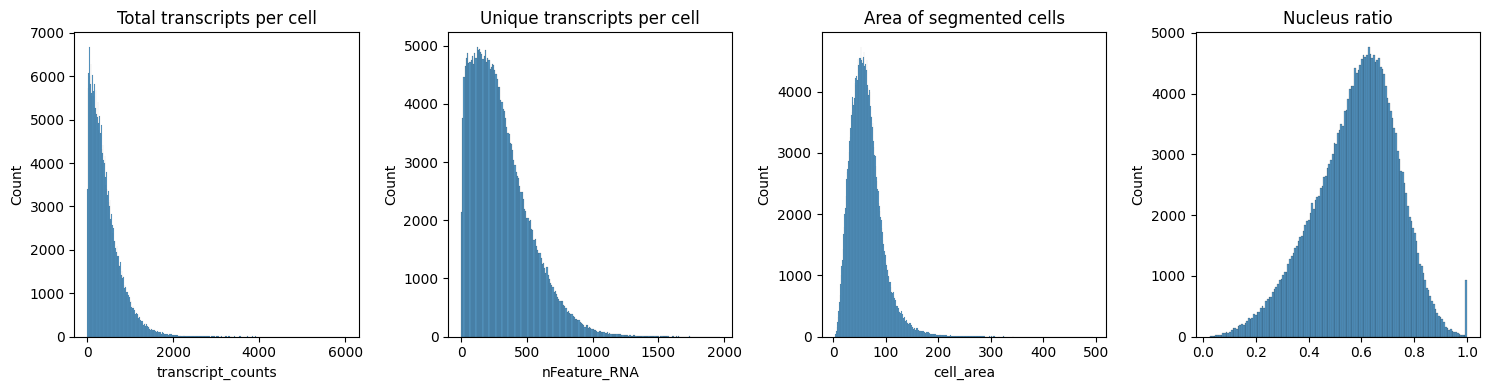

22020263005


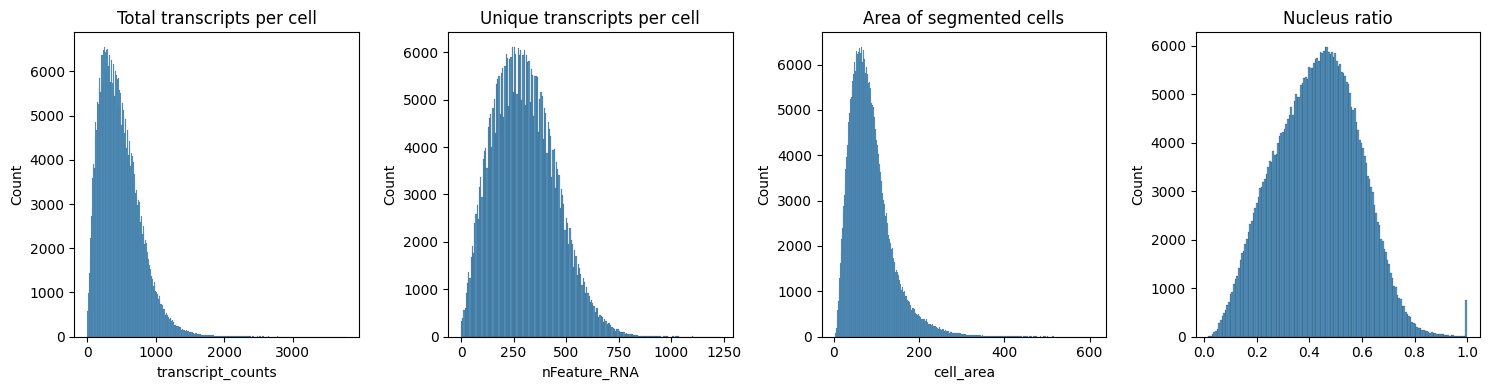

In [4]:
samples = [adata4, adata5]

for i in samples:
    print(i.obs["sample"][0])
    fig, axs = plt.subplots(1, 4, figsize=(15, 4))
    axs[0].set_title("Total transcripts per cell")
    sns.histplot(
        i.obs["transcript_counts"],
        kde=False,
        ax=axs[0],
    )
    axs[1].set_title("Unique transcripts per cell")
    sns.histplot(
        i.obs["nFeature_RNA"],
        kde=False,
        ax=axs[1],
    )
    axs[2].set_title("Area of segmented cells")
    sns.histplot(
        i.obs["cell_area"],
        kde=False,
        ax=axs[2],
    )
    axs[3].set_title("Nucleus ratio")
    sns.histplot(
        i.obs["nucleus_area"] / i.obs["cell_area"],
        kde=False,
        ax=axs[3],
    )
    plt.tight_layout()
    plt.show()

In [5]:
cleaned_samples = []

for i, adata in enumerate(samples):
    # Use a copy to prevent modifying the original objects incorrectly
    temp_adata = adata.copy()
    
    print(f"Processing Sample {i}...")

    # --- FIX 1: Force .X to be a Sparse Matrix (CSR) ---
    # This is the primary data matrix.
    if isinstance(temp_adata.X, pd.DataFrame):
        print(f"  -> Converting DataFrame in .X to Sparse CSR.")
        temp_adata.X = sp.csr_matrix(temp_adata.X.values)
    elif not sp.issparse(temp_adata.X):
        print(f"  -> Converting Dense Array in .X to Sparse CSR.")
        temp_adata.X = sp.csr_matrix(temp_adata.X)
    
    # --- FIX 2: Clean .obs columns (Handles the Categorical TypeError) ---
    for col in temp_adata.obs.columns:
        # Check for complex data types (lists/arrays) that break pandas concat
        check_series = temp_adata.obs[col].astype('object')
        if check_series.apply(lambda x: isinstance(x, (list, np.ndarray))).any():
            print(f"  -> Dropping complex .obs column: {col}")
            del temp_adata.obs[col]
            
    # --- FIX 3: Standardize .obsm (Embeddings) ---
    # Embeddings must be NumPy arrays.
    for key in list(temp_adata.obsm.keys()):
        matrix = temp_adata.obsm[key]
        if isinstance(matrix, pd.DataFrame):
            print(f"  -> Converting DataFrame in .obsm['{key}'] to NumPy array.")
            temp_adata.obsm[key] = matrix.values
        elif sp.issparse(matrix):
            # obsm matrices are usually dense, convert sparse to dense array
            print(f"  -> Converting Sparse matrix in .obsm['{key}'] to Dense NumPy array.")
            temp_adata.obsm[key] = matrix.toarray()

    # --- FIX 4: Standardize .layers ---
    # Layers should also be sparse matrices.
    for key in list(temp_adata.layers.keys()):
        matrix = temp_adata.layers[key]
        if isinstance(matrix, pd.DataFrame):
            print(f"  -> Converting DataFrame in .layers['{key}'] to Sparse CSR.")
            temp_adata.layers[key] = sp.csr_matrix(matrix.values)
        elif not sp.issparse(matrix):
            print(f"  -> Converting Dense Array in .layers['{key}'] to Sparse CSR.")
            temp_adata.layers[key] = sp.csr_matrix(matrix)
            
    # --- FIX 5: Drop .raw (Safety measure) ---
    temp_adata.raw = None 

    cleaned_samples.append(temp_adata)

# 2. Try Concatenation Again
print("\nAttempting Final Concatenation...")
try:
    # Use merge='same' to ensure obsm/layers are only kept if present in ALL objects
    adata_merge = ad.concat(cleaned_samples, join="inner", merge="same")
    print("✅ Success! Objects concatenated.")
    print(adata_merge)
except Exception as e:
    print(f"❌ Failed again: {e}")

Processing Sample 0...
Processing Sample 1...

Attempting Final Concatenation...
✅ Success! Objects concatenated.
AnnData object with n_obs × n_vars = 672439 × 5101
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'nCount_RNA', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'nFeature_RNA', 'sample', 'type', 'tech'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'


/usr/local/lib/python3.8/dist-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [6]:
systemChecks = adata_merge.var_names.str.startswith('SystemControl')
neg_probes = adata_merge.var_names.str.startswith('Negative')

remove = np.add(neg_probes, systemChecks)
keep = np.invert(remove)

adata_merge = adata_merge[:,keep]

In [7]:
sc.pp.filter_cells(adata_merge, min_counts=40)
sc.pp.filter_genes(adata_merge, min_cells=400)

# remove Malat1, mitochondrial genes and hemoglobin genes
malat1 = adata_merge.var_names.str.startswith('MALAT1')
mito_genes = adata_merge.var_names.str.startswith('MT-')
hb_genes = adata_merge.var_names.str.contains('^HB[^(P)]')

remove = np.add(mito_genes, malat1)
remove = np.add(remove, hb_genes)

keep = np.invert(remove)

adata_merge = adata_merge[:,keep]

print(adata_merge.n_obs, adata_merge.n_vars)

/usr/local/lib/python3.8/dist-packages/scanpy/preprocessing/_simple.py:138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_counts'] = number
/usr/local/lib/python3.8/dist-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


653068 4688


/usr/local/lib/python3.8/dist-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [8]:
other_genes = adata_merge.var_names.str.startswith(('UTY','XIST'))
keep = np.invert(other_genes)
adata_merge = adata_merge[:,keep]
print(adata_merge.n_obs, adata_merge.n_vars)

653068 4688


In [9]:
adata_merge.obs['Count_percentile'] = adata_merge.obs['nCount_RNA'].rank(pct=True) * 100

/tmp/ipykernel_43737/2578531437.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_merge.obs['Count_percentile'] = adata_merge.obs['nCount_RNA'].rank(pct=True) * 100
/usr/local/lib/python3.8/dist-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [10]:
keep_str = ["sample",'tech','type']
keep_numer = ['Count_percentile', 'nCount_RNA', 'nFeature_RNA']
keep = keep_str + keep_numer
adata_merge.obs= adata_merge.obs[keep]

del adata_merge.uns
del adata_merge.obsm

# ensure proper data types
for i in keep_str:
    adata_merge.obs[i]= adata_merge.obs[i].astype('str')

for i in keep_numer:
    adata_merge.obs[i]= adata_merge.obs[i].astype('float')

adata_merge.layers["All_counts"] = adata_merge.X

In [11]:
adata_merge.write_h5ad(filename = "/home/levinsj/spatial/adata/project_Files/Fetal/fetal_annotated_AllCells_withXenium.h5ad")